In [13]:
import pathlib
import collections
import random
import statistics as stats

from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = pathlib.Path(".")
LABEL_DIR = DATA_DIR / "train" / "labels"
IMAGE_DIR = DATA_DIR / "train" / "images"

label_files = sorted(LABEL_DIR.glob("*.txt"))
print(f"Found {len(label_files)} label files")


Found 1804 label files


## Quick EDA Checklist ##

In [ ]:
# Build character set/vocabulary
all_labels = []
char_counter = collections.Counter()

for lf in label_files:
    text = lf.read_text(encoding="utf-8").strip()
    all_labels.append(text)
    char_counter.update(text)

vocab = sorted(char_counter.keys())
print("\n=== Character Set / Vocabulary ===")
print(f"Vocab size: {len(vocab)}")
print("Characters (first 80 shown):")
print("".join(vocab[:80]))
print("\nChar frequencies (top 20):")
for ch, cnt in char_counter.most_common(20):
    printable = ch if ch != " " else "<SPACE>"
    print(f"'{printable}': {cnt}")


=== Character Set / Vocabulary ===
Vocab size: 101
Characters (first 80 shown):
 !#'(),-.0123456789:;=?IVX^¶𐐀𐐁𐐂𐐃𐐄𐐅𐐆𐐇𐐈𐐉𐐊𐐌𐐍𐐎𐐏𐐐𐐑𐐒𐐓𐐔𐐕𐐖𐐗𐐘𐐙𐐚𐐛𐐜𐐝𐐞𐐟𐐡𐐢𐐣𐐤𐐨𐐩𐐪𐐫𐐬𐐭𐐮𐐯𐐰𐐱𐐲𐐳𐐴𐐵𐐶𐐷𐐸

Char frequencies (top 20):
'<SPACE>': 15738
'𐑌': 4230
'𐐻': 3577
'𐐮': 3221
'𐑉': 3202
'𐐼': 3161
'𐐯': 2743
'𐑄': 2450
'𐐰': 2437
'𐑅': 2310
'𐐲': 2172
'𐑊': 1851
'𐑋': 1727
'𐐸': 1711
'𐐨': 1655
',': 1622
'𐑆': 1484
'𐐱': 1276
'𐐩': 1255
'𐐭': 1235



=== Sequence Lengths ===
Number of Samples: 1804
Max Length: 77
Min Length: 1
Mean Length: 41.96
Median Length: 45.0
Standard Deviation: 15.14


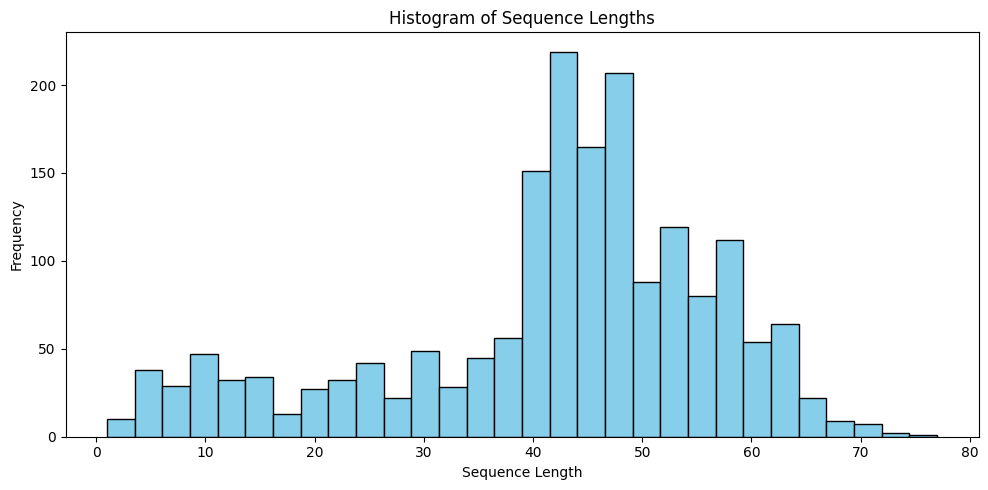

In [ ]:
# Find sequence lengths (use the label strings, not the Path objects)
lengths = [len(label) for label in all_labels]

print("\n=== Sequence Lengths ===")
print(f"Number of Samples: {len(lengths)}")
print(f"Max Length: {max(lengths)}")
print(f"Min Length: {min(lengths)}")
print(f"Mean Length: {stats.mean(lengths):.2f}")
print(f"Median Length: {stats.median(lengths)}")
print(f"Standard Deviation: {stats.stdev(lengths):.2f}")

# Histogram of sequence lengths
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30, color="skyblue", edgecolor="black")
plt.title("Histogram of Sequence Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



=== Image Dimensions ===
Number of Images: 1804
Height - Max: 161, Min: 64, Mean: 93.01, Median: 93.0, StdDev: 8.07
Width  - Max: 1966, Min: 1944, Mean: 1955.92, Median: 1956.0, StdDev: 4.03


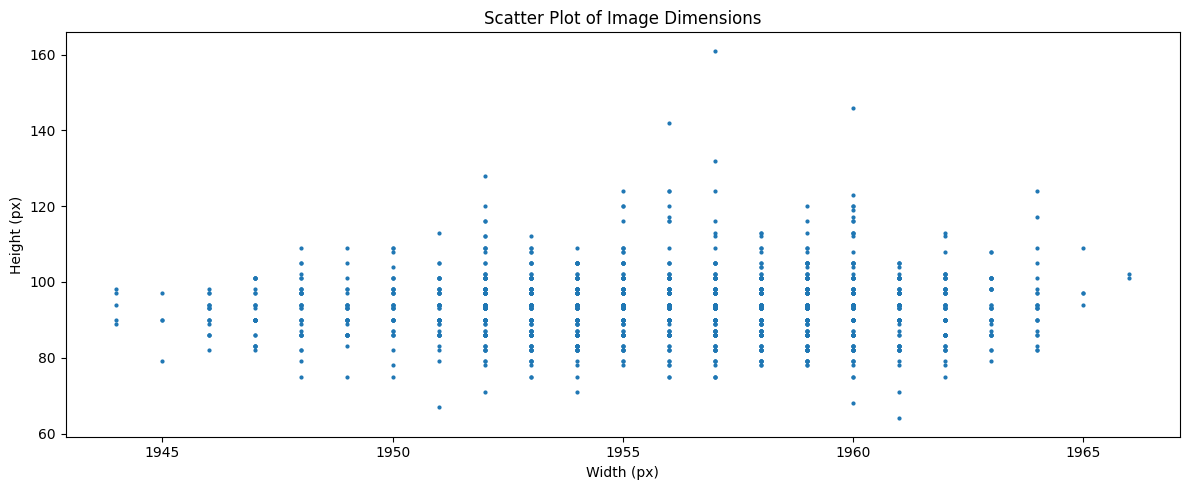

In [11]:
# Image Stats

heights = []
widths = []

image_files = sorted(IMAGE_DIR.glob("*.png"))

for img_path in image_files:
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
    
print("\n=== Image Dimensions ===")
print(f"Number of Images: {len(image_files)}")
print(f"Height - Max: {max(heights)}, Min: {min(heights)}, Mean: {stats.mean(heights):.2f}, Median: {stats.median(heights)}, StdDev: {stats.stdev(heights):.2f}")
print(f"Width  - Max: {max(widths)}, Min: {min(widths)}, Mean: {stats.mean(widths):.2f}, Median: {stats.median(widths)}, StdDev: {stats.stdev(widths):.2f}")

# Histograms of image dimensions
plt.figure(figsize=(12, 5))
plt.scatter(widths, heights, s=4)
plt.title("Scatter Plot of Image Dimensions")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.tight_layout()
plt.show()


=== 5 Random Sample Images and Labels ===


C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66620 (\N{DESERET SMALL LETTER DEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66606 (\N{DESERET SMALL LETTER SHORT I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66629 (\N{DESERET SMALL LETTER ES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66612 (\N{DESERET SMALL LETTER AY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66617 (\N{DESERET SMALL LETTER PEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66634 (\N{DESERE

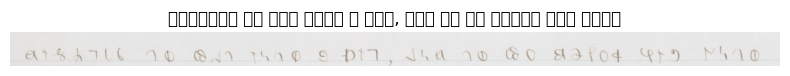

C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66627 (\N{DESERET SMALL LETTER ETH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66609 (\N{DESERET SMALL LETTER SHORT AH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66623 (\N{DESERET SMALL LETTER KAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66626 (\N{DESERET SMALL LETTER VEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66628 (\N{DESERET SMALL LETTER THEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache

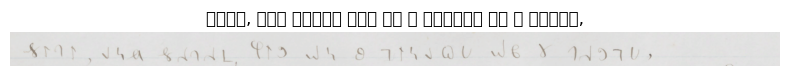

C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66614 (\N{DESERET SMALL LETTER WU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66621 (\N{DESERET SMALL LETTER CHEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66613 (\N{DESERET SMALL LETTER OW}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 66614 (\N{DESERET SMALL LETTER WU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\corbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools

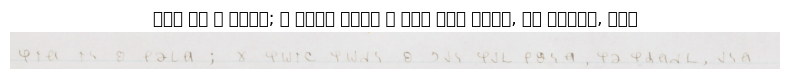

C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66568 (\N{DESERET CAPITAL LETTER SHORT A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66601 (\N{DESERET SMALL LETTER LONG E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66603 (\N{DESERET SMALL LETTER LONG AH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66615 (\N{DESERET SMALL LETTER YEE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 66568 (\N{DESERET CAPITAL LETTER SHORT A}) missing from font(s) DejaVu Sans.
  fi

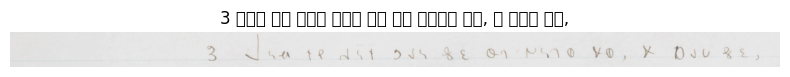

C:\Users\corbe\AppData\Local\Temp\ipykernel_19588\3047428722.py:20: UserWarning: Glyph 66637 (\N{DESERET SMALL LETTER ENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\corbe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 66637 (\N{DESERET SMALL LETTER ENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


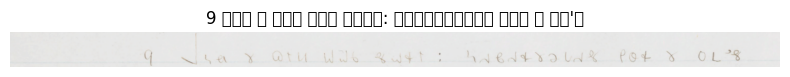

In [ ]:
# Data Quality

def show_random_samples(n=5):
    print(f"\n=== {n} Random Sample Images and Labels ===")
    for _ in range(n):
        lf = random.choice(label_files)
        label = lf.read_text(encoding="utf-8").strip()
        img_id = lf.stem
        img_path = IMAGE_DIR / f"{img_id}.png"

        if not img_path.exists():
            print(f"Image file {img_path} not found for label file {lf}")
            continue

        with Image.open(img_path) as img:
            plt.figure(figsize=(8,2))
            plt.imshow(img, cmap="gray")
            plt.axis("off")
            plt.title(label)
            plt.tight_layout()
            plt.show()

show_random_samples(n=5)
# Need to change font somehow so the labels actually show up